# Выполнил
Трифонов Дмитрий Сергеевич, 12-25РПм, 1 курс, Программная инженерия

# ПРАКТИЧЕСКОЕ ЗАНЯТИЕ 4.1
## Тема: Бинарная классификация текстов с использованием нейронной сети Keras (набор данных IMDb)

### 1. Цели работы
1. Понять задачу бинарной классификации.
2. Научиться подготавливать текстовые данные (векторизация).
3. Построить и обучить нейронную сеть в Keras.
4. Проанализировать переобучение и улучшить модель.

### Шаг 1. Подготовка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb

print("Библиотеки успешно импортированы.")

Библиотеки успешно импортированы.


### Шаг 2. Загрузка набора данных IMDb
Ограничиваем словарь 10,000 самыми частыми словами.

In [2]:
num_words = 10000
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=num_words)

print(f"Размер обучающей выборки: {len(train_data)}")
print(f"Размер тестовой выборки: {len(test_data)}")
print(f"Пример отзыва (индексы): {train_data[0][:10]} ...")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 15s 1us/step
Размер обучающей выборки: 25000
Размер тестовой выборки: 25000
Пример отзыва (индексы): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65] ...


### Шаг 3. Декодирование отзыва (Демонстрация)
Посмотрим, как выглядит отзыв в текстовом виде.

In [3]:
word_index = imdb.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

# Индексы смещены на 3, так как 0, 1 и 2 зарезервированы
decoded_review = " ".join([reverse_word_index.get(i - 3, "?") for i in train_data[0]])
print("Текст отзыва:", decoded_review[:200], "...")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step
Текст отзыва: ? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the sa ...


### Шаг 4. Векторизация данных
Используем One-hot encoding (Multi-hot) для превращения списков индексов в векторы фиксированной длины (10000).

In [4]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

print(f"Размерность x_train после векторизации: {x_train.shape}")

Размерность x_train после векторизации: (25000, 10000)


### Шаг 5. Формирование валидационной выборки
Отделим 10,000 примеров для проверки качества во время обучения.

In [5]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

### Шаг 6. Построение модели
Архитектура: 2 скрытых слоя по 16 нейронов (ReLU) и выходной слой (Sigmoid).

In [6]:
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │         160,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

### Шаг 7. Обучение модели
Запускаем обучение на 20 эпох.

In [7]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.7717 - loss: 0.5267 - val_accuracy: 0.8675 - val_loss: 0.3939
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8916 - loss: 0.3253 - val_accuracy: 0.8674 - val_loss: 0.3388
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9164 - loss: 0.2464 - val_accuracy: 0.8807 - val_loss: 0.2987
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9351 - loss: 0.1974 - val_accuracy: 0.8896 - val_loss: 0.2742
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9421 - loss: 0.1697 - val_accuracy: 0.8863 - val_loss: 0.2764
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9562 - loss: 0.1421 - val_accuracy: 0.8809 - val_loss: 0.2962
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9613 - loss: 0.1218 - val_accuracy: 0.8828 - val_loss: 0.2960
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9673 - loss: 0.1061 - val_accuracy: 0.8769 - v

### Шаг 8. Визуализация результатов
Строим графики потерь (Loss) и точности (Accuracy).

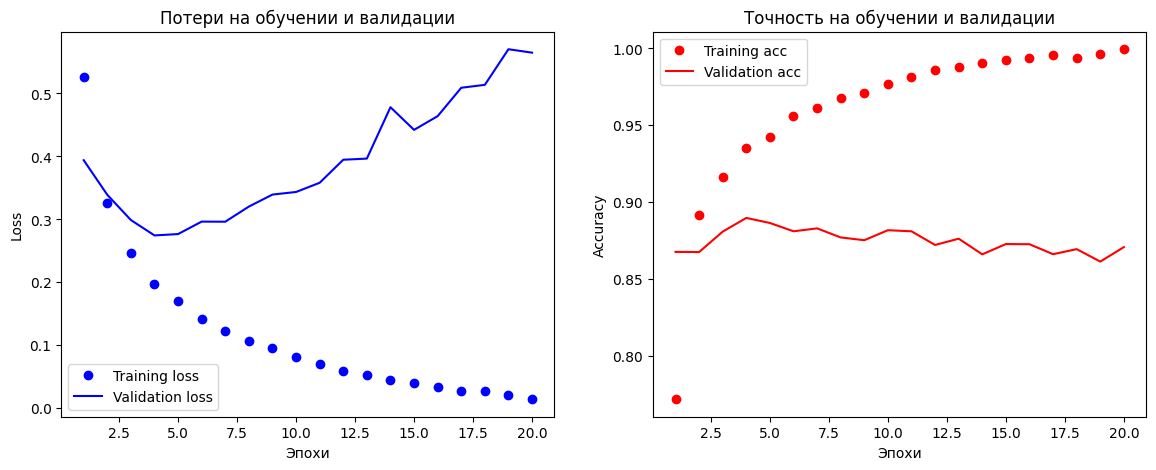

In [8]:
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
acc_values = history_dict["accuracy"]
val_acc_values = history_dict["val_accuracy"]
epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(14, 5))

# График Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Потери на обучении и валидации")
plt.xlabel("Эпохи")
plt.ylabel("Loss")
plt.legend()

# График Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, acc_values, "ro", label="Training acc")
plt.plot(epochs, val_acc_values, "r", label="Validation acc")
plt.title("Точность на обучении и валидации")
plt.xlabel("Эпохи")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Шаг 9. Анализ переобучения
**Вывод:** 
На графиках видно, что потери на валидации (`val_loss`) достигают минимума примерно на **4-й эпохе**, после чего начинают расти, в то время как потери на обучении продолжают падать. Точность на валидации также перестает расти после 4-5 эпохи. Это классическая картина переобучения. 

**Решение:** Обучать модель только 4 эпохи.

### Шаг 10. Финальная модель
Обучаем новую модель с нуля на полных данных (train + val) в течение 4 эпох и оцениваем на тесте.

In [9]:
final_model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

final_model.compile(optimizer="rmsprop",
                    loss="binary_crossentropy",
                    metrics=["accuracy"])

# Обучаем на всем x_train (включая то, что было валидацией)
final_model.fit(x_train, y_train, epochs=4, batch_size=512, verbose=0)

results = final_model.evaluate(x_test, y_test)
print(f"\nФинальные результаты на тесте (Loss, Accuracy): {results}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8875 - loss: 0.2816

Финальные результаты на тесте (Loss, Accuracy): [0.28162941336631775, 0.8874800205230713]


### Шаг 11. Прогнозирование
Предсказание вероятностей для первых 3 примеров из теста.

In [10]:
predictions = final_model.predict(x_test[:3])
print("Предсказания (вероятность положительного отзыва):", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Предсказания (вероятность положительного отзыва): [[0.25678653]
 [0.9991728 ]
 [0.9300871 ]]


## ---
### 2. Индивидуальные исследовательские задания
В рамках исследования выполнены задания: 
1. **Изменение размера скрытых слоев (32 нейрона).**
2. **Добавление слоя Dropout для борьбы с переобучением.**

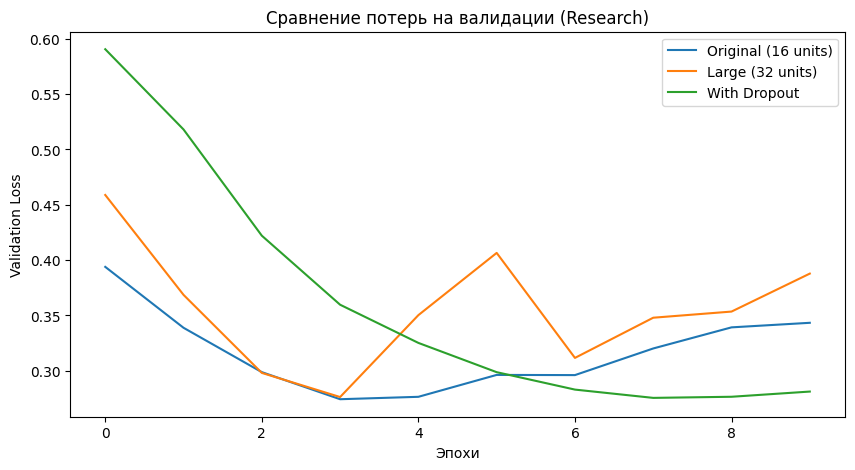

In [11]:
# Задание 1: Увеличение нейронов до 32
model_32 = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(10000,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_32.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
hist_32 = model_32.fit(partial_x_train, partial_y_train, epochs=10, batch_size=512, validation_data=(x_val, y_val), verbose=0)

# Задание 2: Добавление Dropout (0.5)
model_drop = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
model_drop.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
hist_drop = model_drop.fit(partial_x_train, partial_y_train, epochs=10, batch_size=512, validation_data=(x_val, y_val), verbose=0)

# Сравнение графиков
plt.figure(figsize=(10, 5))
plt.plot(history.history['val_loss'][:10], label='Original (16 units)')
plt.plot(hist_32.history['val_loss'], label='Large (32 units)')
plt.plot(hist_drop.history['val_loss'], label='With Dropout')
plt.title('Сравнение потерь на валидации (Research)')
plt.xlabel('Эпохи')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

**Выводы по исследованию:**
1. Увеличение числа нейронов до 32 привело к еще более быстрому переобучению (кривая потерь растет раньше).
2. Использование Dropout значительно замедлило переобучение, позволяя `val_loss` оставаться низким дольше. Это эффективный метод регуляризации.

### 3. Контрольные вопросы

**1. Почему необходимо векторизовать текстовые данные?**
Нейронные сети — это математические модели, которые работают с тензорами (массивами чисел). Они не могут принимать на вход сырой текст или списки разной длины. Векторизация превращает текст в числовые векторы фиксированной размерности.

**2. Как распознать переобучение?**
Переобучение распознается по расхождению графиков: ошибка на тренировочных данных продолжает падать (стремится к 0), в то время как ошибка на валидационных данных перестает падать и начинает расти.

### 4. Итог работы
В ходе работы была решена задача классификации отзывов IMDb. Мы научились подготавливать текстовые данные, построили базовую модель, выявили переобучение на 4-й эпохе и оптимизировали модель. Исследование показало, что Dropout помогает бороться с переобучением лучше, чем простое изменение размера слоев.